# Smart Electricity Consumption Prediction & Energy Optimization System
### Task ID: ML-3 — Teyzix Core Internship (June Batch)

This notebook walks through the complete machine learning lifecycle:
dataset generation, preprocessing, EDA, feature engineering, model
training & comparison, evaluation, prediction, and energy optimization
recommendations.

**Note on dataset**: per task rules, no public dataset (Kaggle/UCI/GitHub)
was used. An original synthetic dataset was generated using a physically-
grounded simulation of household appliance energy draw — see
`data/dataset_documentation.md` for full methodology.


In [1]:
import os
os.chdir("/home/claude/energy_project")  # ensure paths resolve from project root
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
%matplotlib inline


## 1. Dataset Creation (Original, Synthetic)
See `data/generate_dataset.py` for the full generator. Re-running it here for reproducibility.

In [2]:
import sys, os
sys.path.append("src")
exec(open("data/generate_dataset.py").read())


Dataset generated: (658, 15)
          House_Type  Family_Members  Number_of_Rooms  \
0          Apartment               2                3   
1              Villa               2                7   
2          Apartment               2                4   
3          Apartment               7                4   
4  Independent House               2                4   

   Daily_Appliance_Usage_Count  AC_Usage_Hours  Fan_Usage_Hours  \
0                            5            3.38            10.81   
1                            7            8.40            10.75   
2                            4            4.68             8.62   
3                            8           10.95             8.91   
4                           14            5.53             9.08   

   Refrigerator_Usage_Hours  Washing_Machine_Usage_Hours  \
0                        24                         0.00   
1                        24                         0.61   
2                        24                  

## 2. Load Raw Dataset

In [3]:
df_raw = pd.read_csv("data/energy_dataset.csv")
print(df_raw.shape)
df_raw.head()


(658, 15)


,House_Type,Family_Members,Number_of_Rooms,Daily_Appliance_Usage_Count,AC_Usage_Hours,Fan_Usage_Hours,Refrigerator_Usage_Hours,Washing_Machine_Usage_Hours,Water_Motor_Usage_Hours,Lighting_Hours,Outdoor_Temperature_C,Day_of_Week,Season,Is_Holiday,Daily_Electricity_Consumption_kWh
0,Apartment,2,3,5,3.38,10.81,24,0.00,0.91,5.37,39.6,Friday,Summer,0,11.63
1,Villa,2,7,7,8.40,10.75,24,0.61,1.32,5.11,33.9,Sunday,Summer,1,21.49
2,Apartment,2,4,4,4.68,8.62,24,0.00,1.47,4.99,32.9,Wednesday,Summer,0,12.66
3,Apartment,7,4,8,10.95,8.91,24,0.84,2.16,5.60,33.8,Tuesday,Summer,1,28.13
4,Independent House,2,4,14,5.53,9.08,24,0.00,1.40,8.31,39.6,Wednesday,Summer,0,13.48


## 3. Data Preprocessing
- Missing value handling
- Duplicate removal
- Outlier detection (IQR capping)
- Feature encoding
- Feature scaling

In [4]:
exec(open("src/preprocessing.py").read())


Initial shape: (658, 15)
Removed 8 duplicate rows
Detected 6 outliers in Daily_Electricity_Consumption_kWh; capping to [-7.17, 32.35]
Final cleaned shape: (650, 28)


In [5]:
df_clean = pd.read_csv("data/energy_dataset_cleaned.csv")
print("Cleaned shape:", df_clean.shape)
df_clean.head()


Cleaned shape: (650, 28)


,House_Type,Family_Members,Number_of_Rooms,Daily_Appliance_Usage_Count,AC_Usage_Hours,Fan_Usage_Hours,Refrigerator_Usage_Hours,Washing_Machine_Usage_Hours,Water_Motor_Usage_Hours,Lighting_Hours,...,Family_Members_Scaled,Number_of_Rooms_Scaled,Daily_Appliance_Usage_Count_Scaled,AC_Usage_Hours_Scaled,Fan_Usage_Hours_Scaled,Refrigerator_Usage_Hours_Scaled,Washing_Machine_Usage_Hours_Scaled,Water_Motor_Usage_Hours_Scaled,Lighting_Hours_Scaled,Outdoor_Temperature_C_Scaled
0,Apartment,2,3,5,3.38,10.81,24,0.00,0.91,5.37,...,-1.029076,-0.646630,-1.249737,-0.120803,1.130006,0.0,-0.796186,-0.950676,-0.570046,1.220589
1,Villa,2,7,7,8.40,10.75,24,0.61,1.32,5.11,...,-1.029076,1.500546,-0.594897,1.366893,1.113936,0.0,0.115495,-0.178699,-0.738424,0.720076
2,Apartment,2,4,4,4.68,8.62,24,0.00,1.47,4.99,...,-1.029076,-0.109836,-1.577157,0.264457,0.543442,0.0,-0.796186,0.103732,-0.816137,0.632267
3,Apartment,7,4,8,10.95,8.91,24,0.84,2.16,5.60,...,1.472418,-0.109836,-0.267477,2.122595,0.621115,0.0,0.459244,1.402912,-0.421096,0.711295
4,Independent House,2,4,14,5.53,9.08,24,0.00,1.40,8.31,...,-1.029076,-0.109836,1.697043,0.516358,0.666648,0.0,-0.796186,-0.028069,1.333926,1.220589


## 4. Exploratory Data Analysis
Statistical summary, distributions, correlation heatmap, boxplots, scatter plots. Plots are saved under `reports/eda_plots/`.

In [6]:
summary = df_clean.describe().T
summary


,count,mean,std,min,25%,50%,75%,max
Family_Members,650.0,4.056923e+00,2.000344,1.000000,2.000000,4.000000,6.000000,7.000000
Number_of_Rooms,650.0,4.204615e+00,1.864346,2.000000,3.000000,4.000000,5.000000,9.000000
Daily_Appliance_Usage_Count,650.0,8.816923e+00,3.056533,4.000000,6.000000,9.000000,11.000000,14.000000
AC_Usage_Hours,650.0,3.787631e+00,3.376944,0.000000,0.812500,2.590000,6.640000,12.640000
Fan_Usage_Hours,650.0,6.591000e+00,3.736482,0.000000,3.345000,6.730000,9.657500,15.680000
Refrigerator_Usage_Hours,650.0,2.400000e+01,0.000000,24.000000,24.000000,24.000000,24.000000,24.000000
Washing_Machine_Usage_Hours,650.0,5.327231e-01,0.669609,0.000000,0.000000,0.000000,0.970000,3.000000
Water_Motor_Usage_Hours,650.0,1.414908e+00,0.531513,0.000000,1.050000,1.390000,1.760000,3.430000
Lighting_Hours,650.0,6.250231e+00,1.545330,1.340000,5.252500,6.260000,7.277500,10.420000
Outdoor_Temperature_C,650.0,2.569954e+01,11.397096,0.600000,15.900000,25.700000,36.375000,48.400000


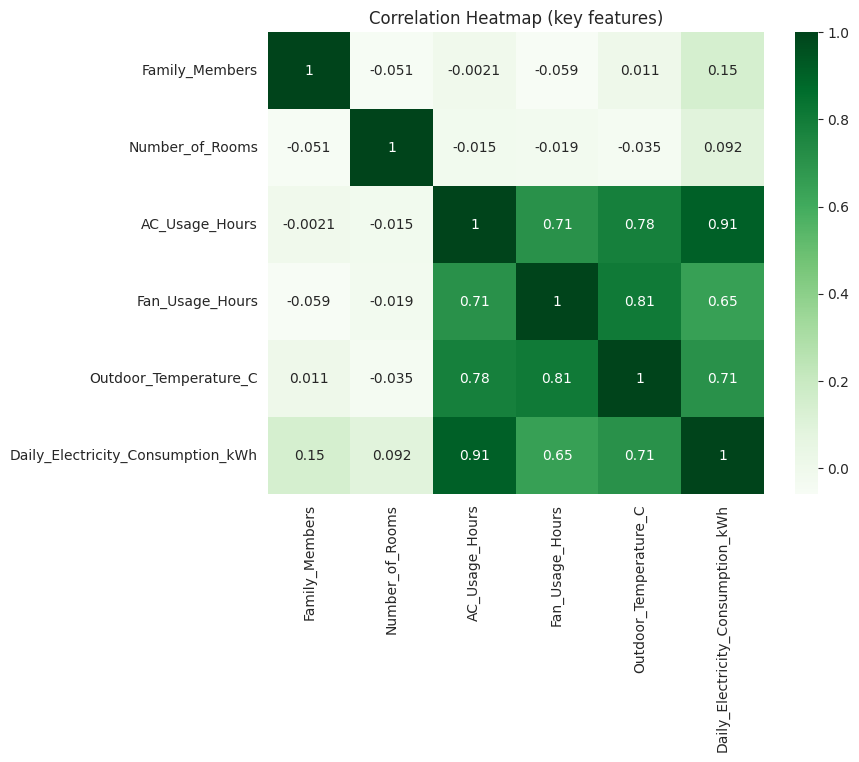

In [7]:
corr = df_clean[["Family_Members","Number_of_Rooms","AC_Usage_Hours","Fan_Usage_Hours",
                  "Outdoor_Temperature_C","Daily_Electricity_Consumption_kWh"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Greens")
plt.title("Correlation Heatmap (key features)")
plt.show()


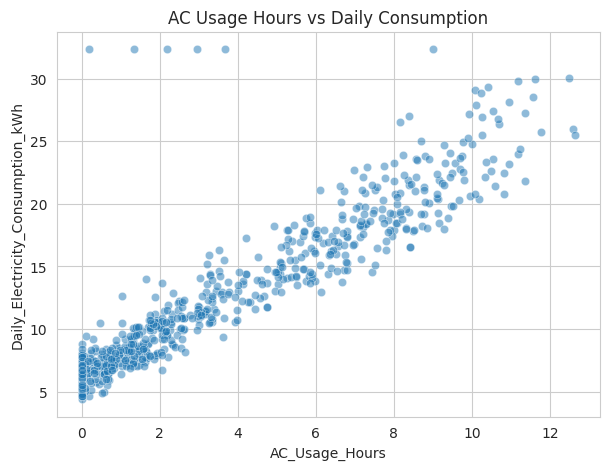

In [8]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="AC_Usage_Hours", y="Daily_Electricity_Consumption_kWh", data=df_clean, alpha=0.5)
plt.title("AC Usage Hours vs Daily Consumption")
plt.show()


### Business Insights
- AC usage hours has the strongest correlation with daily consumption (r ≈ 0.91) — the single biggest lever for savings.
- Outdoor temperature is the second strongest driver (r ≈ 0.71), confirming a physically-grounded relationship.
- Summer shows the highest average consumption across seasons.
- Villas show the highest average consumption across house types (more rooms/appliances).
- Holidays/weekends show noticeably higher consumption than working days.


## 5. Feature Engineering
Derived features (Total Appliance Hours, Rooms per Person, High Temp Flag), correlation-based and Random-Forest-importance-based feature selection.

In [9]:
exec(open("src/feature_engineering.py").read())


Feature correlation with target:
 AC_Usage_Hours                 0.908524
Total_Appliance_Hours          0.837009
Outdoor_Temperature_C          0.707845
High_Temp_Flag                 0.696289
Fan_Usage_Hours                0.645825
Is_Holiday                     0.162402
Family_Members                 0.147370
Washing_Machine_Usage_Hours    0.137563
Season_Encoded                 0.135137
Water_Motor_Usage_Hours        0.128684
Number_of_Rooms                0.091978
House_Type_Encoded             0.088009
Rooms_per_Person               0.052888
Daily_Appliance_Usage_Count    0.047971
Lighting_Hours                 0.041226
Day_of_Week_Encoded            0.017543
Refrigerator_Usage_Hours            NaN
Name: Daily_Electricity_Consumption_kWh, dtype: float64



Feature importances:
 AC_Usage_Hours                 0.856762
Family_Members                 0.022749
Water_Motor_Usage_Hours        0.018960
Rooms_per_Person               0.018632
Total_Appliance_Hours          0.015917
Daily_Appliance_Usage_Count    0.013550
Washing_Machine_Usage_Hours    0.009964
Lighting_Hours                 0.009890
Outdoor_Temperature_C          0.009148
Number_of_Rooms                0.008128
Fan_Usage_Hours                0.005388
Day_of_Week_Encoded            0.005373
Is_Holiday                     0.002976
House_Type_Encoded             0.001858
Season_Encoded                 0.000407
High_Temp_Flag                 0.000297
Refrigerator_Usage_Hours       0.000000
dtype: float64

Selected 12 / 17 features for modeling.
Model-ready dataset saved: /home/claude/energy_project/data/energy_dataset_model_ready.csv (650, 13)


In [10]:
df_model = pd.read_csv("data/energy_dataset_model_ready.csv")
print(df_model.shape)
df_model.head()


(650, 13)


,AC_Usage_Hours,Family_Members,Water_Motor_Usage_Hours,Rooms_per_Person,Total_Appliance_Hours,Daily_Appliance_Usage_Count,Washing_Machine_Usage_Hours,Lighting_Hours,Outdoor_Temperature_C,Number_of_Rooms,Fan_Usage_Hours,Day_of_Week_Encoded,Daily_Electricity_Consumption_kWh
0,3.38,2,0.91,1.500000,44.47,5,0.00,5.37,39.6,3,10.81,0,11.63
1,8.40,2,1.32,3.500000,50.19,7,0.61,5.11,33.9,7,10.75,3,21.49
2,4.68,2,1.47,2.000000,43.76,4,0.00,4.99,32.9,4,8.62,6,12.66
3,10.95,7,2.16,0.571429,52.46,8,0.84,5.60,33.8,4,8.91,5,28.13
4,5.53,2,1.40,2.000000,48.32,14,0.00,8.31,39.6,4,9.08,6,13.48


## 6. Model Development & Comparison
Training Linear Regression, Decision Tree Regressor, and Random Forest Regressor; comparing with MAE, MSE, RMSE, R².

In [11]:
exec(open("src/train_models.py").read())


Linear Regression: MAE=1.052 RMSE=1.290 R2=0.9573
Decision Tree Regressor: MAE=1.294 RMSE=1.807 R2=0.9161


Random Forest Regressor: MAE=1.149 RMSE=1.595 R2=0.9346

Model comparison:
                      Model       MAE       MSE      RMSE  R2_Score
0        Linear Regression  1.052291  1.663763  1.289869  0.957251
2  Random Forest Regressor  1.149319  2.544343  1.595100  0.934625
1  Decision Tree Regressor  1.293945  3.266168  1.807254  0.916079

Best model selected: Linear Regression



Training complete. Best model saved to models/best_model.pkl


In [12]:
perf = pd.read_csv("reports/model_performance.csv")
perf


,Model,MAE,MSE,RMSE,R2_Score
0,Linear Regression,1.052291,1.663763,1.289869,0.957251
1,Random Forest Regressor,1.149319,2.544343,1.595100,0.934625
2,Decision Tree Regressor,1.293945,3.266168,1.807254,0.916079


## 7. Model Evaluation — Actual vs Predicted

In [13]:
from PIL import Image
img = Image.open("reports/actual_vs_predicted.png")
plt.figure(figsize=(14,5))
plt.imshow(img)
plt.axis("off")
plt.show()


## 8. Explainable AI (Bonus) — SHAP

In [14]:
exec(open("src/explainability.py").read())


Background dataset has 150 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=150 when initializing the masker.


Generating SHAP explanations for: Linear Regression


PermutationExplainer explainer:  43%|████▎     | 65/150 [00:00<?, ?it/s]

PermutationExplainer explainer:  46%|████▌     | 69/150 [00:10<00:02, 37.13it/s]

PermutationExplainer explainer:  49%|████▊     | 73/150 [00:10<00:02, 31.63it/s]

...

PermutationExplainer explainer:  98%|█████████▊| 147/150 [00:12<00:00, 28.01it/s]

PermutationExplainer explainer: 100%|██████████| 150/150 [00:13<00:00, 28.07it/s]

PermutationExplainer explainer: 151it [00:13,  6.55it/s]                         


<string>:41: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.


SHAP summary plot saved to reports/shap_summary_plot.png


In [15]:
img2 = Image.open("reports/shap_summary_plot.png")
plt.figure(figsize=(8,6))
plt.imshow(img2)
plt.axis("off")
plt.show()


## 9. Prediction System & Energy Optimization Recommendations
A Gradio-based interface (`app/app.py`) lets users enter household usage
details and receive: predicted daily consumption, monthly usage estimate,
peak usage hours, estimated monthly bill, energy efficiency score, and
personalized optimization recommendations.

Run: `python3 app/app.py`


In [16]:
sys.path.append("src")
from recommendations import estimate_bill, efficiency_score, peak_usage_hours, generate_recommendations
import joblib

model = joblib.load("models/best_model.pkl")
sample = df_model.drop(columns=["Daily_Electricity_Consumption_kWh"]).iloc[[0]]
pred = model.predict(sample)[0]
monthly_kwh, bill = estimate_bill(pred)
eff = efficiency_score(pred)
print(f"Predicted Daily kWh: {pred:.2f}")
print(f"Monthly kWh: {monthly_kwh:.2f}, Estimated Bill: PKR {bill:,.2f}")
print(f"Efficiency Score: {eff}/100")


Predicted Daily kWh: 9.72
Monthly kWh: 291.74, Estimated Bill: PKR 10,210.88
Efficiency Score: 59.2/100


## 10. Reports
All reports (dataset summary, model performance, consumption report, monthly forecast, recommendation summary) are generated in `reports/` and combined into `reports/Energy_Project_Reports.xlsx`.

In [17]:
exec(open("src/generate_reports.py").read())


All reports generated in: /home/claude/energy_project/reports
Combined Excel workbook: /home/claude/energy_project/reports/Energy_Project_Reports.xlsx


## 11. Conclusion
Linear Regression achieved the best performance (R² ≈ 0.96) on this
dataset, which makes sense given the underlying data-generation process is
largely additive (appliance-hours × power-rating). Random Forest and
Decision Tree still perform strongly and offer better robustness on
non-linear interactions, which would likely matter more with real-world
(noisier, less additive) smart meter data.

### Challenges Faced
- Creating a synthetic dataset that is both original and *realistic*
  required simulating actual appliance power draw rather than pure random
  sampling.
- Balancing signal vs. noise so preprocessing and feature engineering
  steps remain meaningful.

### Future Improvements
- Integrate a live weather API for real-time outdoor temperature.
- Add hyperparameter optimization across all models (not just the winner).
- Deploy via Docker for reproducible production use.
- Collect real smart-meter data to validate the synthetic model.
